In [1]:
import os
import sys

try:
    # 1. Check if we are in Colab
    import google.colab
    print("Colab environment detected. Setting up dependencies...")

    # 2. THE GPU SAFETY CHECK
    import subprocess
    if subprocess.run(['which', 'nvidia-smi']).returncode != 0:
        raise RuntimeError("NO GPU DETECTED! Please go to the top menu -> Runtime -> Change runtime type -> select T4 GPU.")

    # 3. Install system dependencies
    !sudo apt-get update -y
    !sudo apt-get install -y xvfb vulkan-tools glslang-tools vulkan-validationlayers-dev

    # Install the video library (dropping strict versioning for Python 3.12 compatibility)
    !pip install av

    # Dynamically install the exact NVIDIA GL driver
    !sudo apt-get install -y libnvidia-gl-$(nvidia-smi --query-gpu=driver_version --format=csv,noheader | cut -d. -f1)

    print("Cloning repositories...")
    if not os.path.exists('/content/vulky'):
        !git clone https://github.com/rendervous/vulky_project.git /content/vulky
    if not os.path.exists('/content/rdv'):
        !git clone https://github.com/rendervous/rdv.git /content/rdv

    # 4. Set up the headless Vulkan environment
    os.environ['DISPLAY'] = ':99'
    os.environ['XDG_RUNTIME_DIR'] = '/tmp/runtime-dir'
    os.makedirs('/tmp/runtime-dir', exist_ok=True)
    os.environ['VK_ICD_FILENAMES'] = '/usr/share/vulkan/icd.d/nvidia_icd.json'

    # Start the invisible monitor
    subprocess.Popen(['Xvfb', ':99', '-screen', '0', '1024x768x24'])

    # 5. Tell Python where to find the source code
    sys.path.append(os.path.abspath('/content/vulky/src'))
    sys.path.append(os.path.abspath('/content/rdv/src'))

except RuntimeError as re:
    print(f"\nCRITICAL ERROR: {re}\n")
    sys.exit(1)
except ImportError:
    print("Executing locally...")
except Exception as e:
    print("Setup failed:", e)

Colab environment detected. Setting up dependencies...
Hit:1 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease     
Hit:3 https://cli.github.com/packages stable InRelease                         
Hit:4 http://security.ubuntu.com/ubuntu jammy-security InRelease               
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease                         
Hit:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease                     
Hit:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease                 
Hit:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease               
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease   
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of

In [2]:
import os
# os.environ['RDV_DEBUG'] = 'True'  ## uncomment to enable debug logging from vulkan
import rdv
import torch
!pip install plyfile

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
/content/vulky/src/vulky/_gmath.py:334: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:357.)
  ret = func(*args, **kwargs)


In [3]:
import numpy as np
from plyfile import PlyData

from google.colab import drive
drive.mount('/content/drive')

# Update this line to point to your new Google Drive path!
ply_path = "/content/drive/MyDrive/Gaussians/bicycle/point_cloud.ply"

print(f"Loading PLY file from {ply_path}... (This might take a few seconds for millions of points)")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading PLY file from /content/drive/MyDrive/Gaussians/bicycle/point_cloud.ply... (This might take a few seconds for millions of points)


In [4]:
def compute_inverse_covariance(scales, rotations):
    """
    Computes the upper triangular 6 elements of the Inverse Covariance Matrix
    formula: Sigma^-1 = R * S^-2 * R^T
    """
    # 1. Square the scales and invert them (S^-2)
    # Add a tiny epsilon to prevent division by zero!
    inv_sq_scales = 1.0 / (scales ** 2 + 1e-7) 
    
    # 2. Convert Quaternions (w, x, y, z) to 3x3 Rotation Matrices (R)
    # (Assuming rotations tensor is shape [N, 4])
    r = rotations[:, 0]
    x = rotations[:, 1]
    y = rotations[:, 2]
    z = rotations[:, 3]
    
    R = torch.zeros((rotations.shape[0], 3, 3), device=scales.device)
    R[:, 0, 0] = 1.0 - 2.0 * (y**2 + z**2)
    R[:, 0, 1] = 2.0 * (x * y - r * z)
    R[:, 0, 2] = 2.0 * (x * z + r * y)
    R[:, 1, 0] = 2.0 * (x * y + r * z)
    R[:, 1, 1] = 1.0 - 2.0 * (x**2 + z**2)
    R[:, 1, 2] = 2.0 * (y * z - r * x)
    R[:, 2, 0] = 2.0 * (x * z - r * y)
    R[:, 2, 1] = 2.0 * (y * z + r * x)
    R[:, 2, 2] = 1.0 - 2.0 * (x**2 + y**2)
    
    # 3. Multiply: R * S^-2 * R^T
    # We do this manually to extract just the 6 symmetric values
    inv_cov = torch.zeros((scales.shape[0], 6), device=scales.device)
    
    for i in range(3):
        for j in range(i, 3):
            # Calculate the dot product for this matrix cell
            val = (R[:, i, 0] * inv_sq_scales[:, 0] * R[:, j, 0] + 
                   R[:, i, 1] * inv_sq_scales[:, 1] * R[:, j, 1] + 
                   R[:, i, 2] * inv_sq_scales[:, 2] * R[:, j, 2])
            
            # Map [0,0], [1,1], [2,2], [0,1], [0,2], [1,2] to the 6 indices
            idx = i * 3 - (i * (i + 1)) // 2 + j
            inv_cov[:, idx] = val
            
    return inv_cov

In [5]:
plydata = PlyData.read(ply_path)
v = plydata['vertex']

# 2. EXTRACT POSITIONS (x, y, z)
# We pull the raw numpy arrays from the file and stack them into a single 3D tensor
x = torch.tensor(v['x'].copy(), dtype=torch.float32)
y = torch.tensor(v['y'].copy(), dtype=torch.float32)
z = torch.tensor(v['z'].copy(), dtype=torch.float32)
positions = torch.stack((x, y, z), dim=-1)

# 3. EXTRACT COLORS (SH to RGB Conversion)
# Extract the Degree 0 Spherical Harmonics (the base color)
f_dc_0 = torch.tensor(v['f_dc_0'].copy(), dtype=torch.float32)
f_dc_1 = torch.tensor(v['f_dc_1'].copy(), dtype=torch.float32)
f_dc_2 = torch.tensor(v['f_dc_2'].copy(), dtype=torch.float32)
sh_dc = torch.stack((f_dc_0, f_dc_1, f_dc_2), dim=-1)

# The official 3DGS math to convert SH base color back to standard RGB [0, 1] space
SH_C0 = 0.28209479177387814
colors = sh_dc * SH_C0 + 0.5
#colors = torch.clamp(colors, 0.0, 1.0) # Ensure colors don't exceed max brightness
colors = torch.pow(colors + 1e-5, 1.0 / 2.2) # Apply gamma correction for more accurate color representation

# 4. SEND TO VULKAN MEMORY
print(f"Successfully loaded {positions.shape[0]} Gaussian splats!")
print("Copying to Vulkan GPU memory...")

# 1. EXTRACT SCALES
# The file saves 'scale_0', 'scale_1', and 'scale_2'
scale_names = ['scale_0', 'scale_1', 'scale_2']
scales = torch.stack([torch.tensor(v[name].copy(), dtype=torch.float32) for name in scale_names], dim=-1)

# CRITICAL MATH: The researchers saved the log() of the scales. 
# We must use exp() to reverse it back to physical size!
scales = torch.exp(scales) 


# 2. EXTRACT ROTATIONS
# The file saves quaternions as 'rot_0', 'rot_1', 'rot_2', 'rot_3'
rot_names = ['rot_0', 'rot_1', 'rot_2', 'rot_3']
rotations = torch.stack([torch.tensor(v[name].copy(), dtype=torch.float32) for name in rot_names], dim=-1)

# CRITICAL MATH: Quaternions must always be normalized (length of 1) 
# otherwise the 3D rotation math will distort the shape.
rotations = torch.nn.functional.normalize(rotations, dim=-1)


# 3. EXTRACT OPACITIES (Might as well grab these while we are here!)
opacities = torch.tensor(v['opacity'].copy(), dtype=torch.float32)
# The file saves inverse-sigmoid. We use sigmoid() to turn it back into a 0.0 to 1.0 percentage.
opacities = torch.sigmoid(opacities)

inv_covs = compute_inverse_covariance(scales, rotations)

# Copy it to Vulkan memory just like the positions!
# (You will also need to copy your 'opacities' tensor)
inv_covs = rdv.tensor_copy(inv_covs)
opacities = rdv.tensor_copy(opacities)



Successfully loaded 6131954 Gaussian splats!
Copying to Vulkan GPU memory...


In [6]:
# import torch

# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# # 1. POSITIONS (Line them up on the Z-axis)
# positions = torch.tensor([
#     [0.0, 0.0, -2.0], # Index 0: Front
#     [0.0, 0.0,  0.0], # Index 1: Middle
#     [0.0, 0.0,  2.0], # Index 2: Back
#     [5.0, 0.0,  0.0]  # Index 3: Decoy (Way off to the right)
# ], dtype=torch.float32, device=device)

# # 2. COLORS (RGB)
# colors = torch.tensor([
#     [1.0, 0.0, 0.0], # Red
#     [0.0, 1.0, 0.0], # Green
#     [0.0, 0.0, 1.0], # Blue
#     [1.0, 1.0, 0.0]  # Yellow
# ], dtype=torch.float32, device=device)

# # 3. OPACITIES (Test the Alpha/Dice Rolls)
# opacities = torch.tensor([
#     0.5,  # 50% solid
#     0.2,  # 20% solid
#     1.0,  # 100% solid (The ray MUST stop here)
#     1.0   # 100% solid
# ], dtype=torch.float32, device=device)

# # 4. SCALES (Physical Radius of 1.0 unit)
# scales = torch.tensor([
#     [1.0, 1.0, 1.0],
#     [1.0, 1.0, 1.0],
#     [1.0, 1.0, 1.0],
#     [1.0, 1.0, 1.0]
# ], dtype=torch.float32, device=device)

# # 5. INVERSE COVARIANCE MATRIX (Skip the Quaternions!)
# # For a perfect sphere with scale=1.0, the inverse covariance is just 1.0 on the diagonals.
# # Layout: [M00, M01, M02, M11, M12, M22]
# inv_covs = torch.tensor([
#     [1.0, 0.0, 0.0, 1.0, 0.0, 1.0],
#     [1.0, 0.0, 0.0, 1.0, 0.0, 1.0],
#     [1.0, 0.0, 0.0, 1.0, 0.0, 1.0],
#     [1.0, 0.0, 0.0, 1.0, 0.0, 1.0]
# ], dtype=torch.float32, device=device)

# # Feed this directly into your map!
# gs_map = rdv.GS3D(positions, colors, inv_covs=inv_covs, opacities=opacities, scales=scales)
# gs_map.build_ads()
# print("Test Scene Built!")

In [7]:

# Ensure positions are mapped to the rdv vec3 format
positions = rdv.vec3(positions).to(rdv.device())
colors = rdv.vec3(colors).to(rdv.device())
scales = rdv.vec3(scales).to(rdv.device())

positions = rdv.tensor_copy(positions)
colors = rdv.tensor_copy(colors)
scales = rdv.tensor_copy(scales)

# 5. BUILD THE ACCELERATION DATA STRUCTURE
gs_map = rdv.GS3D(positions, colors, inv_covs=inv_covs, opacities=opacities,scales=scales)
gs_map.build_ads()

print("Ready to render!")

Ready to render!


/content/vulky/src/vulky/_gmath.py:334: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:357.)
  ret = func(*args, **kwargs)
/content/vulky/src/vulky/_gmath.py:334: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  ret = func(*args, **kwargs)


In [8]:
# # 1. HARDCODE THE CAMERA FOR THE TEST SCENE
# # We placed our Gaussians along the Z-axis at -2, 0, and 2.
# # Let's put the camera at Z = -5 so we can see all of them!
# pos = [0.0, 0.0, -5.0]       # Position (Camera lens)

# # We want to look straight ahead at the center of the world
# target = [0.0, 0.0, 0.0]     # Target (Where the camera is pointing)

# # Standard computer graphics "Up" direction is positive Y
# up = [0.0, 1.0, 0.0]         # Up Vector

# pose_list = pos + target + up

# # Load it into Vulkan memory
# camera_poses = rdv.tensor_copy(torch.tensor(pose_list, dtype=torch.float32).reshape(1, 9))

# # 2. CREATE THE SENSOR
# # Since we don't have a real JSON camera, let's just make a nice 800x800 square window.
# render_width = 800
# render_height = 800

# # Change CENTER to RANDOM to force the ray to slightly shift every sample!
# sensor = rdv.Sensor(1, render_width, render_height, 
#                     samples_location=(rdv.SampleLocation.CORNER, rdv.SampleLocation.RANDOM, rdv.SampleLocation.RANDOM), 
#                     probes_map=rdv.CameraProbes(camera_poses=camera_poses))

# # 3. RENDER AND DISPLAY!
# # Let's use 100 samples so the Monte Carlo dice rolls average out 
# # into a perfectly smooth blend of Red, Green, and Blue.
# print("Rendering Test Gaussians...")
# capture_image = sensor.view(gs_map, samples=1000)

In [9]:
import json

# 1. LOAD THE CAMERAS FILE
# (Change this path to wherever your cameras.json is saved in Google Drive)
cameras_path = "/content/drive/MyDrive/Gaussians/bicycle/cameras.json"
with open(cameras_path, 'r') as f:
    cameras_data = json.load(f)

# 2. GRAB THE FIRST CAMERA
cam = cameras_data[0]

# Extract the position and the 3x3 rotation matrix
pos = np.array(cam['position'])
rot = np.array(cam['rotation'])

# 3. CALCULATE TARGET AND UP VECTORS
# In 3D Gaussian Splatting math, the camera looks down the Z-axis of the rotation matrix.
# The 3rd column of the rotation matrix gives us the "forward" direction.
forward = rot[:, 2] 
# The 2nd column gives us the "up" / "down" orientation. 
up = -rot[:, 1]      

# If we know where the camera is (pos) and which way it's looking (forward), 
# we can create a "target" for rdv to look at by adding them together!
target = pos + forward 

# 4. FORMAT FOR THE RDV SENSOR
pose_list = [
    pos[0], pos[1], pos[2],          # Position (px, py, pz)
    target[0], target[1], target[2], # Target (tx, ty, tz)
    up[0], up[1], up[2]              # Up Vector (ux, uy, uz)
]

print(f"Set camera to position: {pos}")

# Load it into Vulkan memory!
camera_poses = rdv.tensor_copy(torch.tensor(pose_list, dtype=torch.float32).reshape(1, 9))

render_width = int(cam['width'] / 3)
render_height = int(cam['height'] / 3)

# Create the sensor using the real camera's resolution (or scale it down if you want it to render faster)
sensor = rdv.Sensor(1, render_width, render_height, 
                    samples_location=(rdv.SampleLocation.CORNER, rdv.SampleLocation.RANDOM, rdv.SampleLocation.RANDOM), 
                    probes_map=rdv.CameraProbes(camera_poses=camera_poses))

# Render!
capture_image = sensor.view(gs_map, samples=16)

Set camera to position: [-3.00268179  1.40077264 -2.22840056]


In [10]:
# capture the field and get the first image
import time
t = time.perf_counter()
image = capture_image.capture()[0]
print(f"Rendered in {time.perf_counter() - t} seconds")

Rendered in 69.68314806000035 seconds


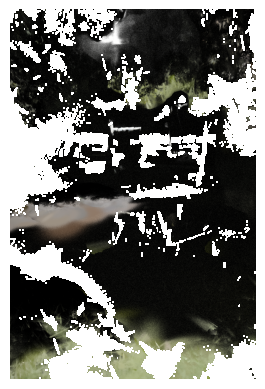

In [11]:
# view the image with matplotlib
import matplotlib.pyplot as plt
plt.imshow(image.cpu().numpy())
plt.gca().axis('off')
plt.gca().invert_yaxis()
plt.show()